In [12]:
import cv2
import albumentations as A
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
import numpy as np
from typing import Tuple, Dict, List

In [27]:
def load_xml_annotations(xml_path: str) -> List[Dict]:
    """
    辅助函数：解析XML标签文件，提取bbox和类别信息
    :param xml_path: XML标签文件路径
    :return: 包含bbox（xmin, ymin, xmax, ymax）和类别的列表
    返回值样例：[{'bbox': (249, 76, 353, 191), 'class': 'red'}]
    """
    # 解析xml文件
    tree = ET.parse(r"D:\yolov5\datasets\seer\labels\1.xml")
    root = tree.getroot()
    size = root.find("size")
    width = int(size.find("width").text)
    height = int(size.find("height").text)
    depth = int(size.find("depth").text)
    print(size)
    print(width)
    print(height)
    annotations = []
    for obj in root.iter("object"):
        cls = obj.find("name").text
        xmlbox = obj.find("bndbox")
        xmin = int(xmlbox.find("xmin").text)
        ymin = int(xmlbox.find("ymin").text)
        xmax = int(xmlbox.find("xmax").text)
        ymax = int(xmlbox.find("ymax").text)
        bbox = (xmin, ymin, xmax, ymax)
        print({bbox},{cls})
        annotations.append({
            'bbox': bbox,
            'class': cls
        })
        
    return annotations

xml_path = r"D:\yolov5\datasets\seer\labels\1.xml"

# 调用函数并打印结果
print(load_xml_annotations(xml_path))

<Element 'size' at 0x000001C7807207C0>
1280
720
{(11, 1, 894, 682)} {'PC'}
{(867, 215, 1007, 493)} {'pen'}
{(1001, 179, 1210, 476)} {'mouse'}
[{'bbox': (11, 1, 894, 682), 'class': 'PC'}, {'bbox': (867, 215, 1007, 493), 'class': 'pen'}, {'bbox': (1001, 179, 1210, 476), 'class': 'mouse'}]


In [46]:
def data_augmentation(image_path: str, mode: str) -> Tuple[np.ndarray, np.ndarray, List[Dict]]:
    """
    数据增强核心方法：区分分类/检测场景，返回原始图、增强图、检测场景的标注（分类场景为空列表）
    :param image_path: 输入图片路径
    :param mode: 增强模式，可选 'classify' 或 'detection'
    :return: (原始图像, 增强后图像, 增强后的标注信息)
    增强后的标注信息样例：[{'bbox': [247.0000147819519, 75.99999904632568, 351.0000228881836, 190.9999966621399], 'class': 'red'}]
    """
    image = cv2.imread(image_path)  # 使用传入的参数而不是硬编码路径
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # 保存原始图片
    original_image = image.copy()

    # 根据你提供的标注数据转换格式
    # 你的标注格式: [{'bbox': (xmin, ymin, xmax, ymax), 'class': '类别名'}]
    # 需要转换为COCO格式: [xmin, ymin, width, height]
    
    # 你提供的标注数据
    annotation_data = [
        {'bbox': (11, 1, 894, 682), 'class': 'PC'},
        {'bbox': (867, 215, 1007, 493), 'class': 'pen'},
        {'bbox': (1001, 179, 1210, 476), 'class': 'mouse'}
    ]
    
    # 从标注数据中提取边界框和类别
    bboxes = []
    category_ids = []
    class_names = []
    
    # 类别名称到ID的映射
    class_mapping = {'PC': 0, 'pen': 1, 'mouse': 2}
    
    for ann in annotation_data:
        # 从(xmin, ymin, xmax, ymax)转换为COCO格式(xmin, ymin, width, height)
        xmin, ymin, xmax, ymax = ann['bbox']
        width = xmax - xmin
        height = ymax - ymin
        
        bboxes.append([xmin, ymin, width, height])
        class_names.append(ann['class'])
        category_ids.append(class_mapping[ann['class']])

    transform = A.Compose(
        [A.RandomSizedBBoxSafeCrop(width=100, height=82, erosion_rate=0.2)],
        bbox_params=A.BboxParams(format='coco', label_fields=['category_ids'])
    )
    
    # 应用变换
    transformed = transform(
        image=image,
        bboxes=bboxes,
        category_ids=category_ids
    )
    
    transformed_image = transformed['image']
    transformed_bboxes = transformed['bboxes']
    transformed_categories = transformed['category_ids']
    
    # 准备返回的标注信息列表
    annotations = []
    
    # 提前定义 id_to_class，避免引用前未赋值错误
    id_to_class = {v: k for k, v in class_mapping.items()}  # 移到这里
    
    # 如果是检测模式，生成标注信息
    if mode == 'detection' and transformed_bboxes:
        for bbox, category_id in zip(transformed_bboxes, transformed_categories):
            xmin, ymin, width, height = bbox
            xmax = xmin + width
            ymax = ymin + height
            
            class_name = id_to_class.get(category_id, f"class_{category_id}")
            
            annotation = {
                'bbox': [float(xmin), float(ymin), float(xmax), float(ymax)],
                'class': class_name
            }
            annotations.append(annotation)
    
    # 只有在检测模式下才绘制边界框
    if mode == 'detection' and transformed_bboxes:
        for i, (bbox, category_id) in enumerate(zip(transformed_bboxes, transformed_categories)):
            xmin, ymin, width, height = bbox
            x1, y1 = int(xmin), int(ymin)
            x2, y2 = int(xmin + width), int(ymin + height)
            
            # 获取类别名称
            class_name = id_to_class.get(category_id, f"class_{category_id}")
            
            # 在变换后的图片上绘制
            cv2.rectangle(transformed_image, (x1, y1), (x2, y2), (0, 0, 255), 1)
            cv2.putText(transformed_image, class_name, (int(xmin), int(ymin) + 20), 
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1)
            
            # 在控制台打印每个框的信息
            print(f"框 {i+1}: 位置[{x1}, {y1}, {x2}, {y2}], 类别: {class_name}")
        
        # 显示
        plt.imshow(transformed_image)
        plt.title(f"数据增强结果 - 共检测到{len(transformed_bboxes)}个目标")
        plt.show()
    else:
        # 分类模式，只显示图片
        plt.imshow(transformed_image)
        plt.title("数据增强结果 - 分类模式")
        plt.show()
    
    # 返回结果
    return original_image, transformed_image, annotations

In [43]:
def visualize_augmentation(img_ori: np.ndarray, img_aug: np.ndarray, annotations: List[Dict], mode: str):
    """
    可视化增强结果：对比显示原始图和增强图，检测场景绘制bbox
    :param img_ori: 原始图像
    :param img_aug: 增强后图像
    :param annotations: 增强后的标注信息（检测场景有效）
    :param mode: 可视化模式，可选 'classify' 或 'detection'
    无返回值，直接展示图片即可
    """
    fig, (ax1, ax2) = plt.subplots(1,2,figsize=(12,6))
    ax1.imshow(img_ori), ax1.axis('off'), ax1.set_title(f'{mode} - Original')
    ax2.imshow(img_aug), ax2.axis('off'), ax2.set_title(f'{mode} - Augmented')
    
    if mode == 'detection' and annotations:
        for ann in annotations:
            x1,y1,x2,y2 = [int(v) for v in ann['bbox']]
            rect = plt.Rectangle((x1,y1),x2-x1,y2-y1,edgecolor='red',facecolor='none',linewidth=1)
            ax2.add_patch(rect)
            ax2.text(x1,y1-10,ann['class'],color='red',fontsize=8,bbox=dict(fc='white',ec='red',alpha=0.8))
    
    # 阻塞显示：关闭当前图后才会执行后续代码
    plt.show(block=True)

D:\jiqixuexi\envs\yolo\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
D:\jiqixuexi\envs\yolo\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 31867 (\N{CJK UNIFIED IDEOGRAPH-7C7B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
D:\jiqixuexi\envs\yolo\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 27169 (\N{CJK UNIFIED IDEOGRAPH-6A21}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
D:\jiqixuexi\envs\yolo\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 24335 (\N{CJK UNIFIED IDEOGRAPH-5F0F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


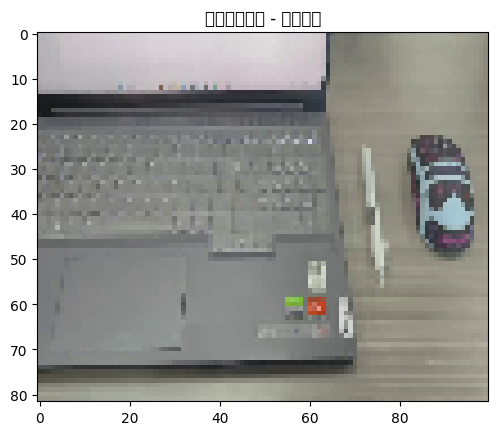

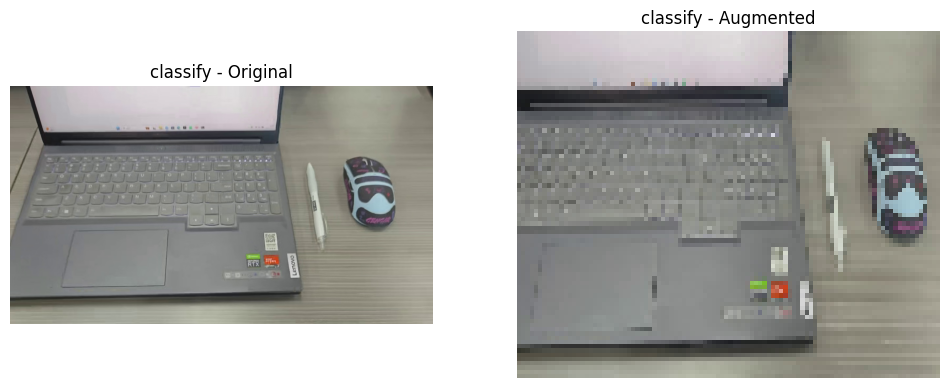

框 1: 位置[0, 0, 80, 82], 类别: PC
框 2: 位置[78, 20, 91, 58], 类别: pen
框 3: 位置[90, 15, 100, 55], 类别: mouse


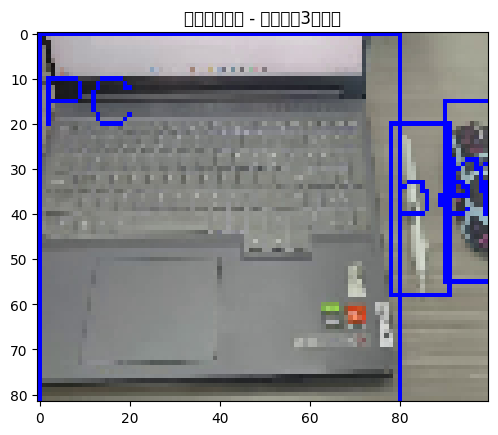

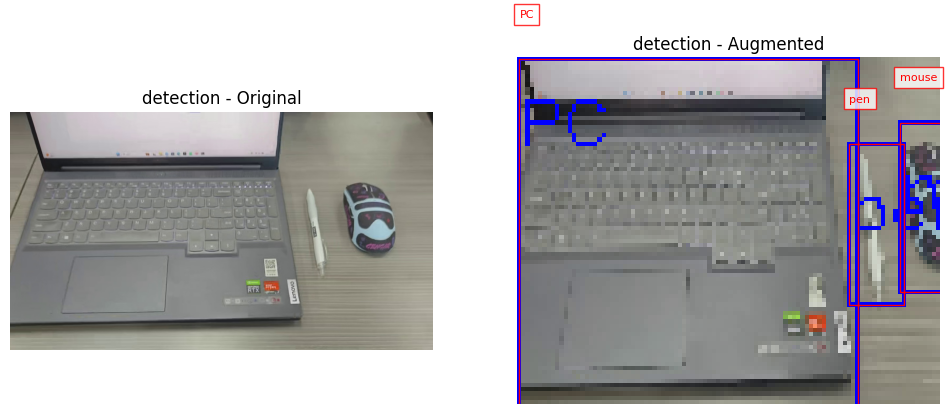

In [47]:
def main(image_path: str, mode: str):
    """
    主函数：一键调用增强+可视化
    :param image_path: 图片路径（如 'test.jpg'）
    :param mode: 模式，可选 'classify' 或 'detection'
    """
    img_ori, img_aug, anns = data_augmentation(image_path, mode)
    visualize_augmentation(img_ori, img_aug, anns, mode)

if __name__ == '__main__':
    main(r"C:\Users\31440\Desktop\yolov8\datasets\images\train\1.jpg", 'classify')  # 分类模式
    main(r"C:\Users\31440\Desktop\yolov8\datasets\images\train\1.jpg", 'detection') # 检测模式